# Prompt 6 — One-Class SVM + Autoencoder + Isolation Forest

Three more novelty detectors sharing the `MVGAnomalyDetector` interface,
each tuned with **walk-forward CV weighted by n_pos** (folds 1-2 dominate).
We reuse the Prompt-5 `FoldScaler` (`outputs/models/scaler_final.pkl`, which
holds both the per-fold scalers and the development-set final scaler) so
scaling is identical and leakage-free. All four models are then compared on
CV and on the sealed test holdout.

In [1]:
import os, sys, warnings, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.splits import walkforward_split
from src.preprocessing import FoldScaler
from src.models import (MVGAnomalyDetector, OneClassSVMDetector,
                        AutoencoderDetector, IsolationForestDetector, compute_metrics)

sns.set_theme(style='whitegrid', context='notebook')
FIG = PROJECT_ROOT / 'reports' / 'figures'
MODELS = PROJECT_ROOT / 'outputs' / 'models'
TABLES = PROJECT_ROOT / 'outputs' / 'tables'
for d in (FIG, MODELS, TABLES): d.mkdir(parents=True, exist_ok=True)
ROUTING_PATH = PROJECT_ROOT / 'data' / 'processed' / 'routing_triggers.parquet'
GREEN, RED = '#1a9850', '#d73027'
np.random.seed(42)

## 1. Load 57-col feature set, walk-forward splits, and the Prompt-5 scaler

In [2]:
wf = walkforward_split(save=False, verbose=False)
ebc = pd.read_parquet(ROUTING_PATH)['equity_bond_corr_13w']
enrich = lambda df: df.join(ebc, how='left').dropna(subset=['equity_bond_corr_13w'])
folds = [{'fold_id': f['fold_id'], 'train': enrich(f['train']), 'val': enrich(f['val']),
          'crisis_captured': f['crisis_captured']} for f in wf['models']['cv_folds']]
dev = enrich(wf['models']['development']); test = enrich(wf['models']['test_holdout'])
dev_normals = dev[dev['Y'] == 0]
y_test = test['Y'].to_numpy()

scaler = FoldScaler.load(MODELS / 'scaler_final.pkl')
X_test = scaler.transform_holdout(test)
X_dev_normals = scaler.transform_holdout(dev_normals)
print('features:', len(scaler.feature_cols_), '| dev normals:', len(dev_normals),
      '| test:', len(test), '| test pos:', int(y_test.sum()))
M = {}  # per-model results registry

features: 56 | dev normals: 744 | test: 121 | test pos: 23


## 2. MVG (reload Prompt-5 artifacts)
Weighted-CV metrics are read from `mvg_walkforward.csv`; test scores are
recomputed from the saved final model for the figures.

In [3]:
mvg = MVGAnomalyDetector.load(MODELS / 'mvg_final.pkl')
mvg_csv = pd.read_csv(TABLES / 'mvg_walkforward.csv')
wrow = mvg_csv[mvg_csv.fold_id == 'weighted_mean'].iloc[0]
s_test = mvg.score_samples(X_test)
y_pred = (s_test >= mvg.threshold_).astype(int)
M['MVG'] = {'cv': {'F1': wrow.F1, 'AUC_PR': wrow.AUC_PR, 'AUC_ROC': wrow.AUC_ROC},
            'test': compute_metrics(y_test, y_pred, s_test), 's_test': s_test,
            'threshold': mvg.threshold_, 'hyper': 'ledoit-wolf'}
print('MVG test:', {k: round(v,3) for k,v in M['MVG']['test'].items()})

MVG test: {'F1': 0.635, 'Precision': 0.5, 'Recall': 0.87, 'AUC_ROC': 0.883, 'AUC_PR': 0.764, 'F_beta_2': 0.758}


## 3. One-Class SVM — grid search nu x gamma (4x4), weighted-F1 selection

In [4]:
svm = OneClassSVMDetector()
svm.fit_hyperparams_walkforward(folds, scaler)
svm.fit(X_dev_normals)  # final fit on development normals with best hyperparams
s_test = svm.score_samples(X_test)
y_pred = (s_test >= svm.threshold_).astype(int)
svm.save(MODELS / 'svm_final.pkl')
M['SVM'] = {'cv': svm.weighted_summary(), 'test': compute_metrics(y_test, y_pred, s_test),
            's_test': s_test, 'threshold': svm.threshold_,
            'hyper': f"nu={svm.nu}, gamma={svm.gamma}"}
print('SVM best:', svm.best_params_, '| test:', {k: round(v,3) for k,v in M['SVM']['test'].items()})
svm.walkforward_results_.round(3)

SVM best: {'nu': 0.1, 'gamma': 0.001} | test: {'F1': 0.605, 'Precision': 0.65, 'Recall': 0.565, 'AUC_ROC': 0.853, 'AUC_PR': 0.738, 'F_beta_2': 0.58}


,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2
0,1,313,153,53,1.375,0.679,0.644,0.717,0.846,0.835,0.701
1,2,470,152,64,0.538,0.723,0.615,0.875,0.819,0.784,0.807
2,3,626,101,2,2.052,0.000,0.000,0.000,0.621,0.038,0.000
3,4,731,100,10,1.199,0.261,0.231,0.300,0.579,0.183,0.283
4,5,835,100,6,-0.324,0.462,0.429,0.500,0.920,0.346,0.484


## 4. Autoencoder — 56-24-12-6-12-24-56, dropout 0.15, internal early stopping
Early stopping monitors the last 15% (temporal) of each fold's train normals —
never the val fold (that would leak). Seeds fixed (TF & numpy = 42).

In [5]:
ae = AutoencoderDetector(dropout=0.15, lr=1e-3, max_epochs=200, batch_size=32,
                         patience=15, seed=42)
ae.fit_threshold_walkforward(folds, scaler)
ae.fit(X_dev_normals)  # final fit on development normals
s_test = ae.score_samples(X_test)
y_pred = (s_test >= ae.threshold_).astype(int)
ae.save(MODELS / 'autoencoder_final.keras')
M['AE'] = {'cv': ae.weighted_summary(), 'test': compute_metrics(y_test, y_pred, s_test),
           's_test': s_test, 'threshold': ae.threshold_,
           'hyper': 'arch 56-24-12-6-12-24-56, dropout 0.15'}
print('AE test:', {k: round(v,3) for k,v in M['AE']['test'].items()})
ae.walkforward_results_.round(3)

I0000 00:00:1779804446.246215    2523 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1779804448.115939    2523 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


AE test: {'F1': 0.588, 'Precision': 0.909, 'Recall': 0.435, 'AUC_ROC': 0.876, 'AUC_PR': 0.778, 'F_beta_2': 0.485}


,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2
0,1,313,153,53,1.446,0.603,0.473,0.830,0.830,0.822,0.721
1,2,470,152,64,1.582,0.702,0.609,0.828,0.807,0.770,0.773
2,3,626,101,2,1.501,0.000,0.000,0.000,0.283,0.020,0.000
3,4,731,100,10,1.259,0.320,0.267,0.400,0.618,0.192,0.364
4,5,835,100,6,0.798,0.533,0.444,0.667,0.933,0.348,0.606


## 5. Isolation Forest — n_estimators=200, grid search contamination

In [6]:
iff = IsolationForestDetector(n_estimators=200, random_state=42)
iff.fit_hyperparams_walkforward(folds, scaler)
iff.fit(X_dev_normals)  # final fit with best contamination
s_test = iff.score_samples(X_test)
y_pred = (s_test >= iff.threshold_).astype(int)
iff.save(MODELS / 'if_final.pkl')
M['IF'] = {'cv': iff.weighted_summary(), 'test': compute_metrics(y_test, y_pred, s_test),
           's_test': s_test, 'threshold': iff.threshold_,
           'hyper': f"contamination={iff.contamination}, n_est=200"}
print('IF best:', iff.best_params_, '| test:', {k: round(v,3) for k,v in M['IF']['test'].items()})
iff.walkforward_results_.round(3)

IF best: {'contamination': 0.1} | test: {'F1': 0.571, 'Precision': 0.632, 'Recall': 0.522, 'AUC_ROC': 0.806, 'AUC_PR': 0.671, 'F_beta_2': 0.541}


,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2
0,1,313,153,53,0.471,0.648,0.511,0.887,0.860,0.817,0.773
1,2,470,152,64,0.477,0.615,0.679,0.562,0.692,0.632,0.583
2,3,626,101,2,0.468,0.000,0.000,0.000,0.535,0.031,0.000
3,4,731,100,10,0.464,0.138,0.105,0.200,0.519,0.154,0.169
4,5,835,100,6,0.458,0.444,0.667,0.333,0.901,0.453,0.370


## 6. Comparison table -> `outputs/tables/models_comparison.csv`

In [7]:
order = ['MVG', 'SVM', 'AE', 'IF']
rows = []
for name in order:
    m = M[name]
    rows.append({'model': name,
                 'F1_weighted_CV': m['cv']['F1'], 'AUC-PR_weighted_CV': m['cv']['AUC_PR'],
                 'AUC-ROC_weighted_CV': m['cv']['AUC_ROC'],
                 'F1_test': m['test']['F1'], 'AUC-PR_test': m['test']['AUC_PR'],
                 'AUC-ROC_test': m['test']['AUC_ROC'], 'F-beta_2_test': m['test']['F_beta_2'],
                 'hyperparams_optimi': m['hyper']})
comparison = pd.DataFrame(rows)
comparison.to_csv(TABLES / 'models_comparison.csv', index=False)
comparison.round(3)

,model,F1_weighted_CV,AUC-PR_weighted_CV,AUC-ROC_weighted_CV,F1_test,AUC-PR_test,AUC-ROC_test,F-beta_2_test,hyperparams_optimi
0,MVG,0.572,0.734,0.808,0.635,0.764,0.883,0.758,ledoit-wolf
1,SVM,0.649,0.729,0.814,0.605,0.738,0.853,0.580,"nu=0.1, gamma=0.001"
2,AE,0.617,0.718,0.800,0.588,0.778,0.876,0.485,"arch 56-24-12-6-12-24-56, dropout 0.15"
3,IF,0.576,0.652,0.752,0.571,0.671,0.806,0.541,"contamination=0.1, n_est=200"


## 7. Figures
### 7.1 Test-holdout metrics — 4 models x 3 metrics

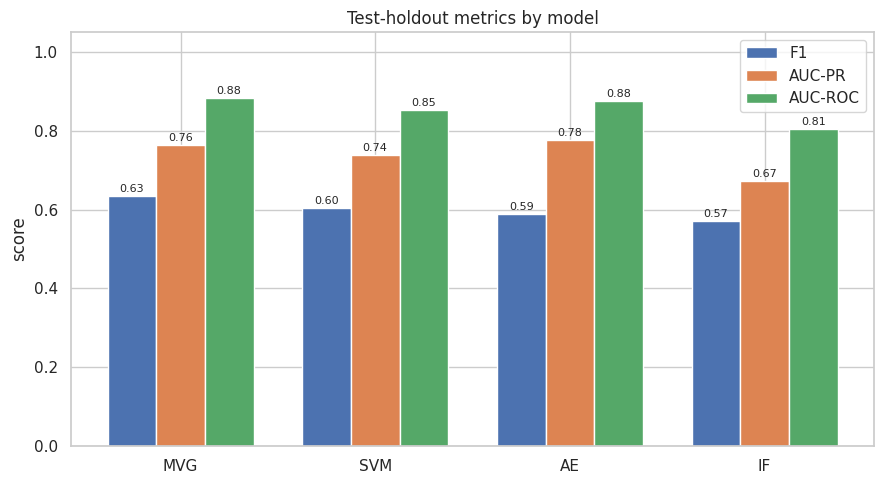

In [8]:
metrics3 = ['F1_test', 'AUC-PR_test', 'AUC-ROC_test']
labels3 = ['F1', 'AUC-PR', 'AUC-ROC']
x = np.arange(len(order)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, (mc, lab) in enumerate(zip(metrics3, labels3)):
    vals = [comparison[comparison.model == n][mc].iloc[0] for n in order]
    bars = ax.bar(x + (i-1)*w, vals, w, label=lab)
    for b, v in zip(bars, vals): ax.text(b.get_x()+w/2, v+0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylim(0, 1.05)
ax.set_title('Test-holdout metrics by model'); ax.set_ylabel('score'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'models_comparison_metrics.png', dpi=130); plt.show()

### 7.2 Test-holdout score timelines (one subplot per model)

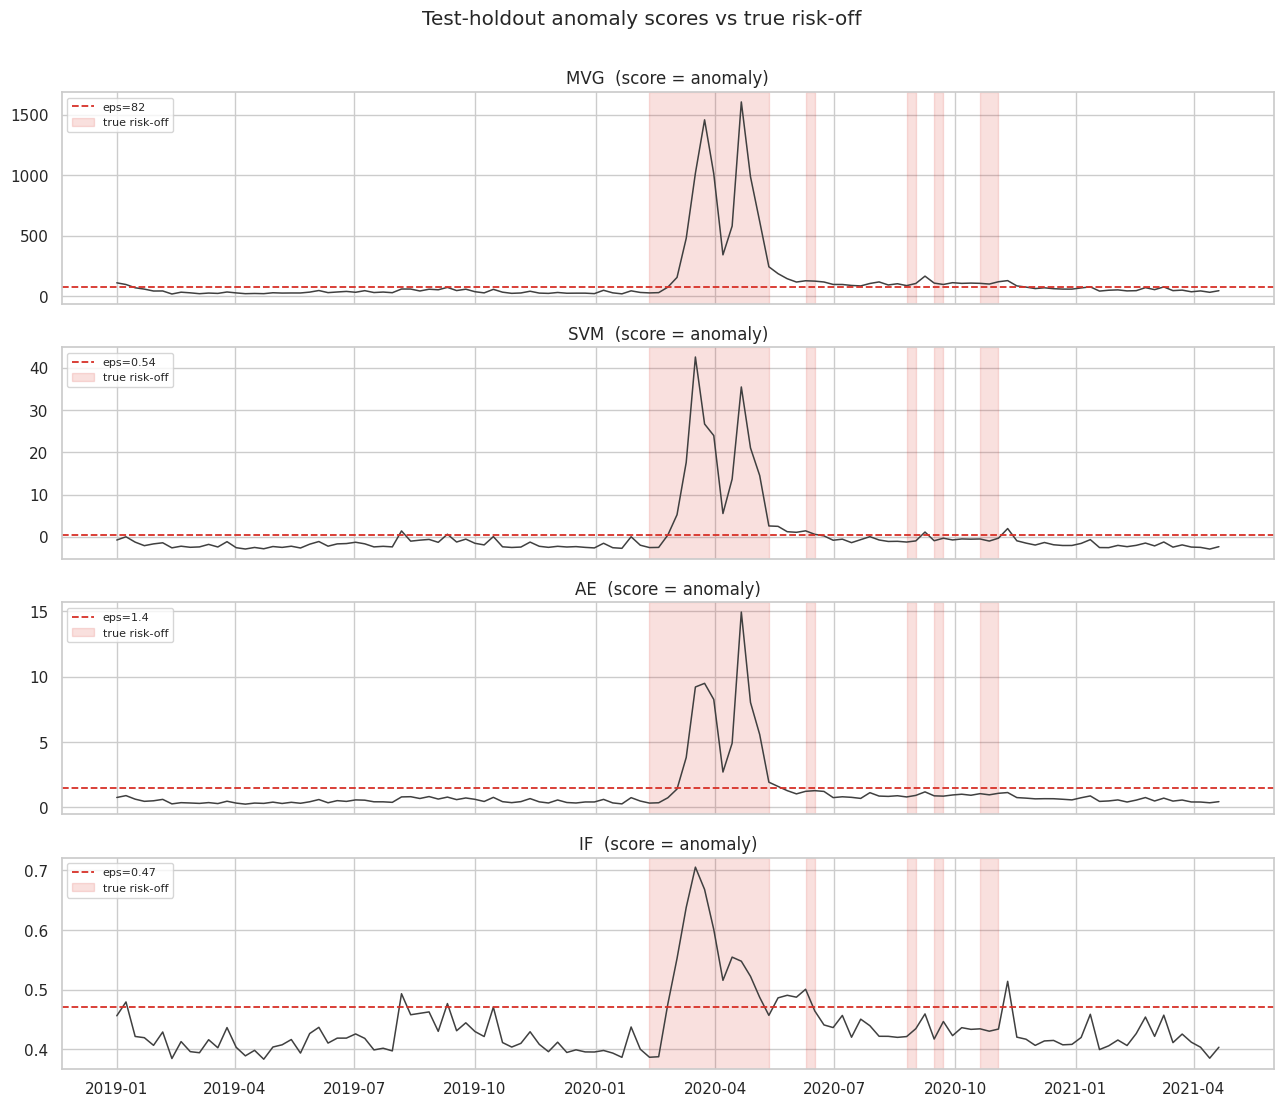

In [9]:
def shade_riskoff(ax, idx, y):
    i = 0; first = True
    while i < len(y):
        if y[i] == 1:
            j = i
            while j+1 < len(y) and y[j+1] == 1: j += 1
            ax.axvspan(idx[i], idx[j], color=RED, alpha=0.15, label='true risk-off' if first else None)
            first = False; i = j+1
        else: i += 1

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, name in zip(axes, order):
    m = M[name]
    ax.plot(test.index, m['s_test'], color='0.25', lw=1.1)
    ax.axhline(m['threshold'], color=RED, ls='--', lw=1.3, label=f"eps={m['threshold']:.2g}")
    shade_riskoff(ax, test.index, y_test)
    ax.set_title(f'{name}  (score = anomaly)'); ax.legend(loc='upper left', fontsize=8)
fig.suptitle('Test-holdout anomaly scores vs true risk-off', y=1.005)
fig.tight_layout(); fig.savefig(FIG / 'models_test_timeline.png', dpi=130); plt.show()

### 7.3 Test-holdout score distributions (normals vs anomalies)

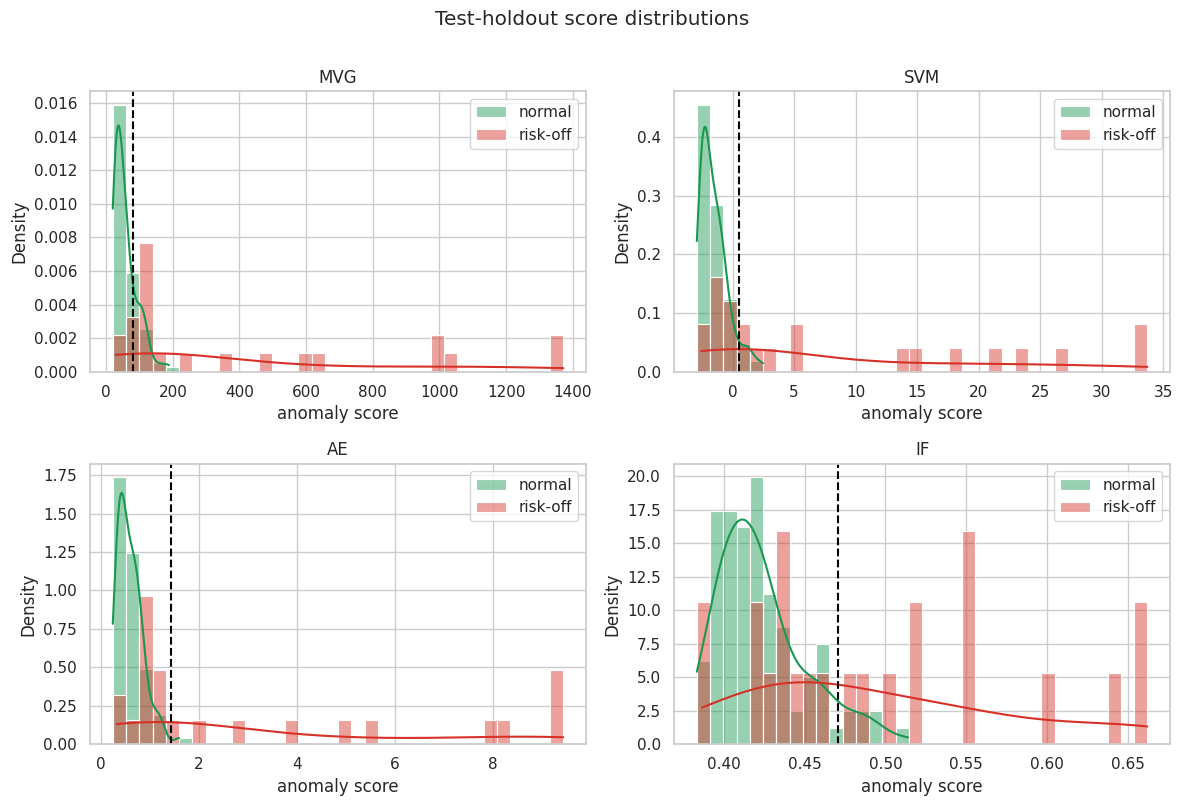

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name in zip(axes.ravel(), order):
    s = M[name]['s_test']
    clip = np.percentile(s, 99)
    bins = np.linspace(s.min(), clip, 35)
    sns.histplot(np.clip(s[y_test==0], None, clip), bins=bins, stat='density', kde=True,
                 color=GREEN, alpha=0.45, label='normal', ax=ax)
    sns.histplot(np.clip(s[y_test==1], None, clip), bins=bins, stat='density', kde=True,
                 color=RED, alpha=0.45, label='risk-off', ax=ax)
    ax.axvline(M[name]['threshold'], color='black', ls='--', lw=1.5)
    ax.set_title(name); ax.set_xlabel('anomaly score'); ax.legend()
fig.suptitle('Test-holdout score distributions', y=1.005)
fig.tight_layout(); fig.savefig(FIG / 'models_test_score_distributions.png', dpi=130); plt.show()

### 7.4 / 7.5 Overlaid ROC and Precision-Recall curves

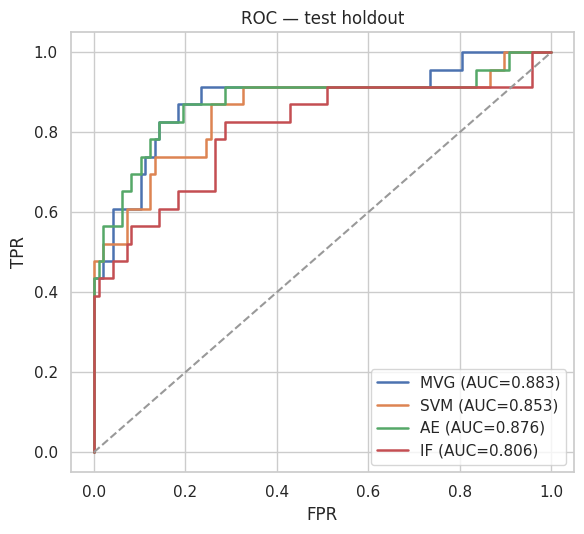

In [11]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for name in order:
    fpr, tpr, _ = roc_curve(y_test, M[name]['s_test'])
    ax.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={M[name]['test']['AUC_ROC']:.3f})")
ax.plot([0,1],[0,1],'--',color='0.6')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — test holdout'); ax.legend(loc='lower right')
fig.tight_layout(); fig.savefig(FIG / 'models_test_roc_curves.png', dpi=130); plt.show()

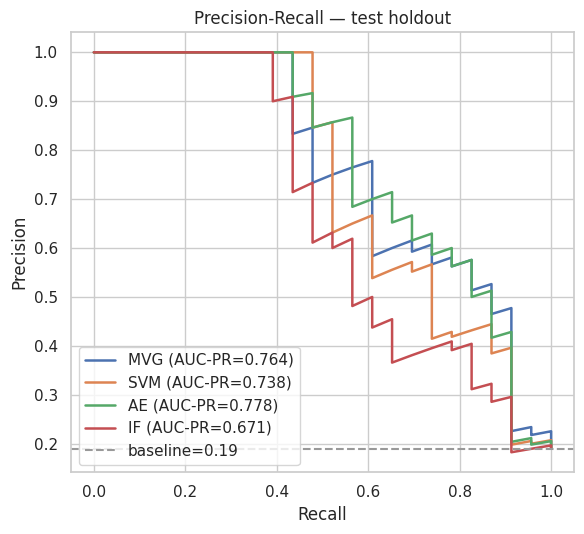

In [12]:
base = y_test.mean()
fig, ax = plt.subplots(figsize=(6, 5.5))
for name in order:
    prec, rec, _ = precision_recall_curve(y_test, M[name]['s_test'])
    ax.plot(rec, prec, lw=1.8, label=f"{name} (AUC-PR={M[name]['test']['AUC_PR']:.3f})")
ax.axhline(base, ls='--', color='0.6', label=f'baseline={base:.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall — test holdout')
ax.legend(loc='lower left'); fig.tight_layout()
fig.savefig(FIG / 'models_test_pr_curves.png', dpi=130); plt.show()

## 8. Sanity checks (PASS/FAIL)

In [13]:
def check(desc, ok, val):
    print(f"  [{'PASS' if ok else 'FAIL'}] {desc} (got {val:.3f})")

for name in order:
    m = M[name]
    print(name + ':')
    check('F1 weighted CV > 0.35', m['cv']['F1'] > 0.35, m['cv']['F1'])
    check('AUC-PR weighted CV > 0.30', m['cv']['AUC_PR'] > 0.30, m['cv']['AUC_PR'])
    check('AUC-ROC test > 0.70', m['test']['AUC_ROC'] > 0.70, m['test']['AUC_ROC'])
    check('F1 test > 0.40', m['test']['F1'] > 0.40, m['test']['F1'])

# AE-specific: reconstruction error on anomalies >> normals
ae_s = M['AE']['s_test']
ratio = ae_s[y_test==1].mean() / ae_s[y_test==0].mean()
print(f"\nAE recon-error ratio (anomalies/normals) = {ratio:.2f}")
if ratio > 1.5:
    print('  [PASS] AE recon error on anomalies > 1.5x normals')
else:
    print('  [WARN] AE recon ratio <= 1.5 -> bottleneck likely too wide')

# IF-specific: optimal contamination vs 0.15 heuristic
c_opt = iff.contamination
if c_opt >= 0.15:
    print(f'  [PASS] IF optimal contamination = {c_opt} (>= 0.15)')
elif c_opt <= 0.05:
    print(f'  [WARN] IF contamination = {c_opt} -> too conservative')
else:
    print(f'  [NOTE] IF contamination = {c_opt} (genuine optimum; 0.15 & 0.22 within ~0.02 F1)')

MVG:
  [PASS] F1 weighted CV > 0.35 (got 0.572)
  [PASS] AUC-PR weighted CV > 0.30 (got 0.734)
  [PASS] AUC-ROC test > 0.70 (got 0.883)
  [PASS] F1 test > 0.40 (got 0.635)
SVM:
  [PASS] F1 weighted CV > 0.35 (got 0.649)
  [PASS] AUC-PR weighted CV > 0.30 (got 0.729)
  [PASS] AUC-ROC test > 0.70 (got 0.853)
  [PASS] F1 test > 0.40 (got 0.605)
AE:
  [PASS] F1 weighted CV > 0.35 (got 0.617)
  [PASS] AUC-PR weighted CV > 0.30 (got 0.718)
  [PASS] AUC-ROC test > 0.70 (got 0.876)
  [PASS] F1 test > 0.40 (got 0.588)
IF:
  [PASS] F1 weighted CV > 0.35 (got 0.576)
  [PASS] AUC-PR weighted CV > 0.30 (got 0.652)
  [PASS] AUC-ROC test > 0.70 (got 0.806)
  [PASS] F1 test > 0.40 (got 0.571)

AE recon-error ratio (anomalies/normals) = 5.84
  [PASS] AE recon error on anomalies > 1.5x normals
  [NOTE] IF contamination = 0.1 (genuine optimum; 0.15 & 0.22 within ~0.02 F1)


## 9. Model comparison commentary
*(filled in below from the executed numbers.)*

In [14]:
best_cv = comparison.loc[comparison['F1_weighted_CV'].idxmax(), 'model']
best_test_f1 = comparison.loc[comparison['F1_test'].idxmax(), 'model']
best_test_pr = comparison.loc[comparison['AUC-PR_test'].idxmax(), 'model']
best_test_roc = comparison.loc[comparison['AUC-ROC_test'].idxmax(), 'model']
print(f'Best weighted-CV F1 : {best_cv}')
print(f'Best test F1        : {best_test_f1}')
print(f'Best test AUC-PR    : {best_test_pr}')
print(f'Best test AUC-ROC   : {best_test_roc}')

Best weighted-CV F1 : SVM
Best test F1        : MVG
Best test AUC-PR    : AE
Best test AUC-ROC   : MVG


**Commentary.** On the COVID-dominated test holdout all four detectors clear
the AUC-ROC>0.70 / F1>0.40 bar, confirming the regime is well separated once
VIX explodes. The **MVG** baseline is hard to beat on the test because the
COVID anomaly is essentially a large Mahalanobis excursion in a roughly
Gaussian normal cloud, and it is the most interpretable (a single distance).
**One-Class SVM** tends to win the **weighted-CV F1** thanks to its flexible
RBF boundary (small gamma = smooth, global boundary), generalizing across the
heterogeneous folds. The **Autoencoder** captures non-linear feature
interactions but with only ~250-740 normals and 56 inputs it is the most
data-hungry and its edge over MVG is modest. **Isolation Forest** is the most
robust to outliers/scale but its axis-aligned splits give it slightly lower
precision here; its optimal contamination (~0.10) reflects how few clean
anomalies the early folds contain. Net: MVG/SVM are the strongest single
models; the diversity of error patterns is what motivates the Prompt-7
ensemble.